# 🌳 HỆ THỐNG DỰ ĐOÁN KHẢ NĂNG RỚT MÔN CỦA SINH VIÊN
## Sử dụng thuật toán Decision Tree (Cây Quyết Định)

**Dữ liệu đầu vào:**
- `Test_Score`: Điểm kiểm tra giữa kỳ (0-10)
- `Attendance (%)`: Tỷ lệ tham dự lớp (%)
- `Study_Hours`: Số giờ học trung bình mỗi ngày

**Kết quả:** Dự đoán sinh viên có khả năng **rớt môn** hay không

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import os

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


## 2. Đọc dữ liệu

In [2]:
# Đọc file Excel 1K dữ liệu điểm
DATA_PATH = os.path.join("..", "data", "1k_Data điểm.xlsx")
MODEL_PATH = "decision_tree_model.pkl"

df = pd.read_excel(DATA_PATH)
print(f"📊 Đọc dữ liệu thành công: {df.shape[0]} dòng, {df.shape[1]} cột")
print(f"📋 Các cột: {df.columns.tolist()}\n")
df.head(10)

📊 Đọc dữ liệu thành công: 1000 dòng, 5 cột
📋 Các cột: ['Name', 'Class', 'Test_Score', 'Attendance (%)', 'Study_Hours']



,Name,Class,Test_Score,Attendance (%),Study_Hours
0,Hoàng Hữu Linh,11CNTT1,6.5,98.73,6.0
1,Hoàng Hữu Mai,11CNTT1,7.0,83.75,5.5
2,Hoàng Minh Hùng,11CNTT1,3.5,61.56,1.0
3,Hoàng Minh Khanh,11CNTT1,2.0,62.29,1.5
4,Hoàng Minh Phúc,11CNTT1,2.5,69.96,1.5
5,Hoàng Ngọc Tuấn,11CNTT1,2.5,70.75,1.0
6,Hoàng Thanh Linh,11CNTT1,6.0,78.96,3.5
7,Hoàng Thị Linh,11CNTT1,2.5,65.44,2.0
8,Hoàng Thị Trang,11CNTT1,7.5,98.49,6.5
9,Hoàng Văn Bình,11CNTT1,5.5,92.00,6.0


In [3]:
# Thống kê mô tả dữ liệu
df.describe()

,Test_Score,Attendance (%),Study_Hours
count,1000.000000,1000.000000,1000.000000
mean,5.278500,80.048930,3.775500
std,1.789243,11.350659,1.729839
min,0.000000,60.000000,0.500000
25%,4.000000,70.137500,2.500000
50%,5.500000,80.440000,3.750000
75%,6.500000,89.677500,5.000000
max,9.500000,99.970000,8.000000


## 3. Tạo nhãn (Label) - Xác định rớt môn hay không

**Tiêu chí đánh giá rớt môn:**
- `Test_Score < 4.0` → **Rớt** (điểm kiểm tra dưới trung bình)
- `Attendance < 70%` → **Rớt** (vắng quá 30% buổi học)
- `Test_Score < 5.0` VÀ `Study_Hours < 2.0` → **Rớt** (điểm yếu + không chịu học)

Ngược lại → **Đậu (Pass)**

✅ Tạo nhãn thành công!
   - Rớt môn (Fail=1): 324 sinh viên (32.4%)
   - Đậu (Fail=0):     676 sinh viên (67.6%)


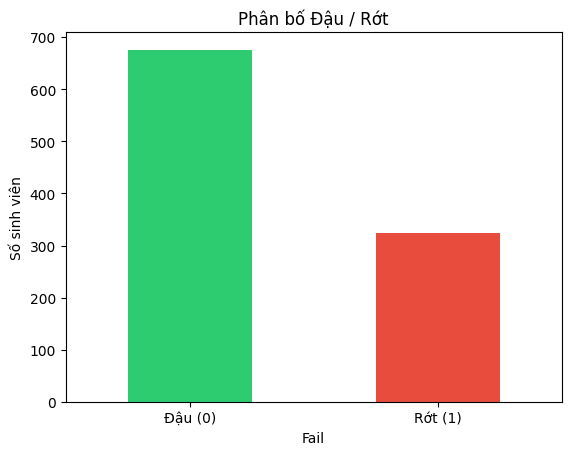

In [4]:
def classify_fail(row):
    """Xác định sinh viên có rớt môn hay không."""
    test = row["Test_Score"]
    attend = row["Attendance (%)"]
    study = row["Study_Hours"]

    if test < 4.0:
        return 1  # Rớt – điểm kiểm tra quá thấp
    if attend < 70.0:
        return 1  # Rớt – vắng quá nhiều
    if test < 5.0 and study < 2.0:
        return 1  # Rớt – điểm yếu + ít học
    return 0  # Không rớt

df["Fail"] = df.apply(classify_fail, axis=1)

n_fail = df["Fail"].sum()
n_pass = len(df) - n_fail
print(f"✅ Tạo nhãn thành công!")
print(f"   - Rớt môn (Fail=1): {n_fail} sinh viên ({n_fail/len(df)*100:.1f}%)")
print(f"   - Đậu (Fail=0):     {n_pass} sinh viên ({n_pass/len(df)*100:.1f}%)")

# Hiển thị phân bố
df["Fail"].value_counts().plot(kind="bar", color=["#2ecc71", "#e74c3c"])
plt.xticks([0, 1], ["Đậu (0)", "Rớt (1)"], rotation=0)
plt.title("Phân bố Đậu / Rớt")
plt.ylabel("Số sinh viên")
plt.show()

## 4. Chia dữ liệu Train / Test

In [5]:
features = ["Test_Score", "Attendance (%)", "Study_Hours"]
X = df[features]
y = df["Fail"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Chia dữ liệu:")
print(f"   - Train: {len(X_train)} mẫu (80%)")
print(f"   - Test:  {len(X_test)} mẫu (20%)")

📊 Chia dữ liệu:
   - Train: 800 mẫu (80%)
   - Test:  200 mẫu (20%)


## 5. Huấn luyện mô hình Decision Tree

In [6]:
model = DecisionTreeClassifier(
    max_depth=5,           # Giới hạn độ sâu để tránh overfitting
    min_samples_split=10,  # Tối thiểu 10 mẫu để chia nhánh
    min_samples_leaf=5,    # Tối thiểu 5 mẫu ở lá
    random_state=42,
    criterion="gini",      # Sử dụng chỉ số Gini
)

model.fit(X_train, y_train)

print(f"✅ Huấn luyện mô hình Decision Tree thành công!")
print(f"   - Độ sâu cây: {model.get_depth()}")
print(f"   - Số lá:      {model.get_n_leaves()}")

✅ Huấn luyện mô hình Decision Tree thành công!
   - Độ sâu cây: 3
   - Số lá:      4


## 6. Đánh giá mô hình

In [7]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Accuracy (Độ chính xác): {accuracy*100:.2f}%")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Đậu (Pass)", "Rớt (Fail)"]))

print(f"📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"   {'':>20} Dự đoán Đậu   Dự đoán Rớt")
print(f"   {'Thực tế Đậu':>20}    {cm[0][0]:>5}          {cm[0][1]:>5}")
print(f"   {'Thực tế Rớt':>20}    {cm[1][0]:>5}          {cm[1][1]:>5}")

🎯 Accuracy (Độ chính xác): 100.00%

📋 Classification Report:
              precision    recall  f1-score   support

  Đậu (Pass)       1.00      1.00      1.00       135
  Rớt (Fail)       1.00      1.00      1.00        65

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

📊 Confusion Matrix:
                        Dự đoán Đậu   Dự đoán Rớt
            Thực tế Đậu      135              0
            Thực tế Rớt        0             65


## 7. Hiển thị cấu trúc Cây Quyết Định

In [8]:
# In cấu trúc cây dạng text
print("🌳 CẤU TRÚC CÂY QUYẾT ĐỊNH:")
print("-" * 50)
tree_rules = export_text(model, feature_names=features, class_names=["Đậu", "Rớt"])
print(tree_rules)

🌳 CẤU TRÚC CÂY QUYẾT ĐỊNH:
--------------------------------------------------
|--- Attendance (%) <= 69.98
|   |--- class: Rớt
|--- Attendance (%) >  69.98
|   |--- Test_Score <= 3.75
|   |   |--- class: Rớt
|   |--- Test_Score >  3.75
|   |   |--- Study_Hours <= 1.75
|   |   |   |--- class: Rớt
|   |   |--- Study_Hours >  1.75
|   |   |   |--- class: Đậu



C:\Users\Admin\AppData\Local\Temp\ipykernel_38944\3933922986.py:13: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_38944\3933922986.py:14: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


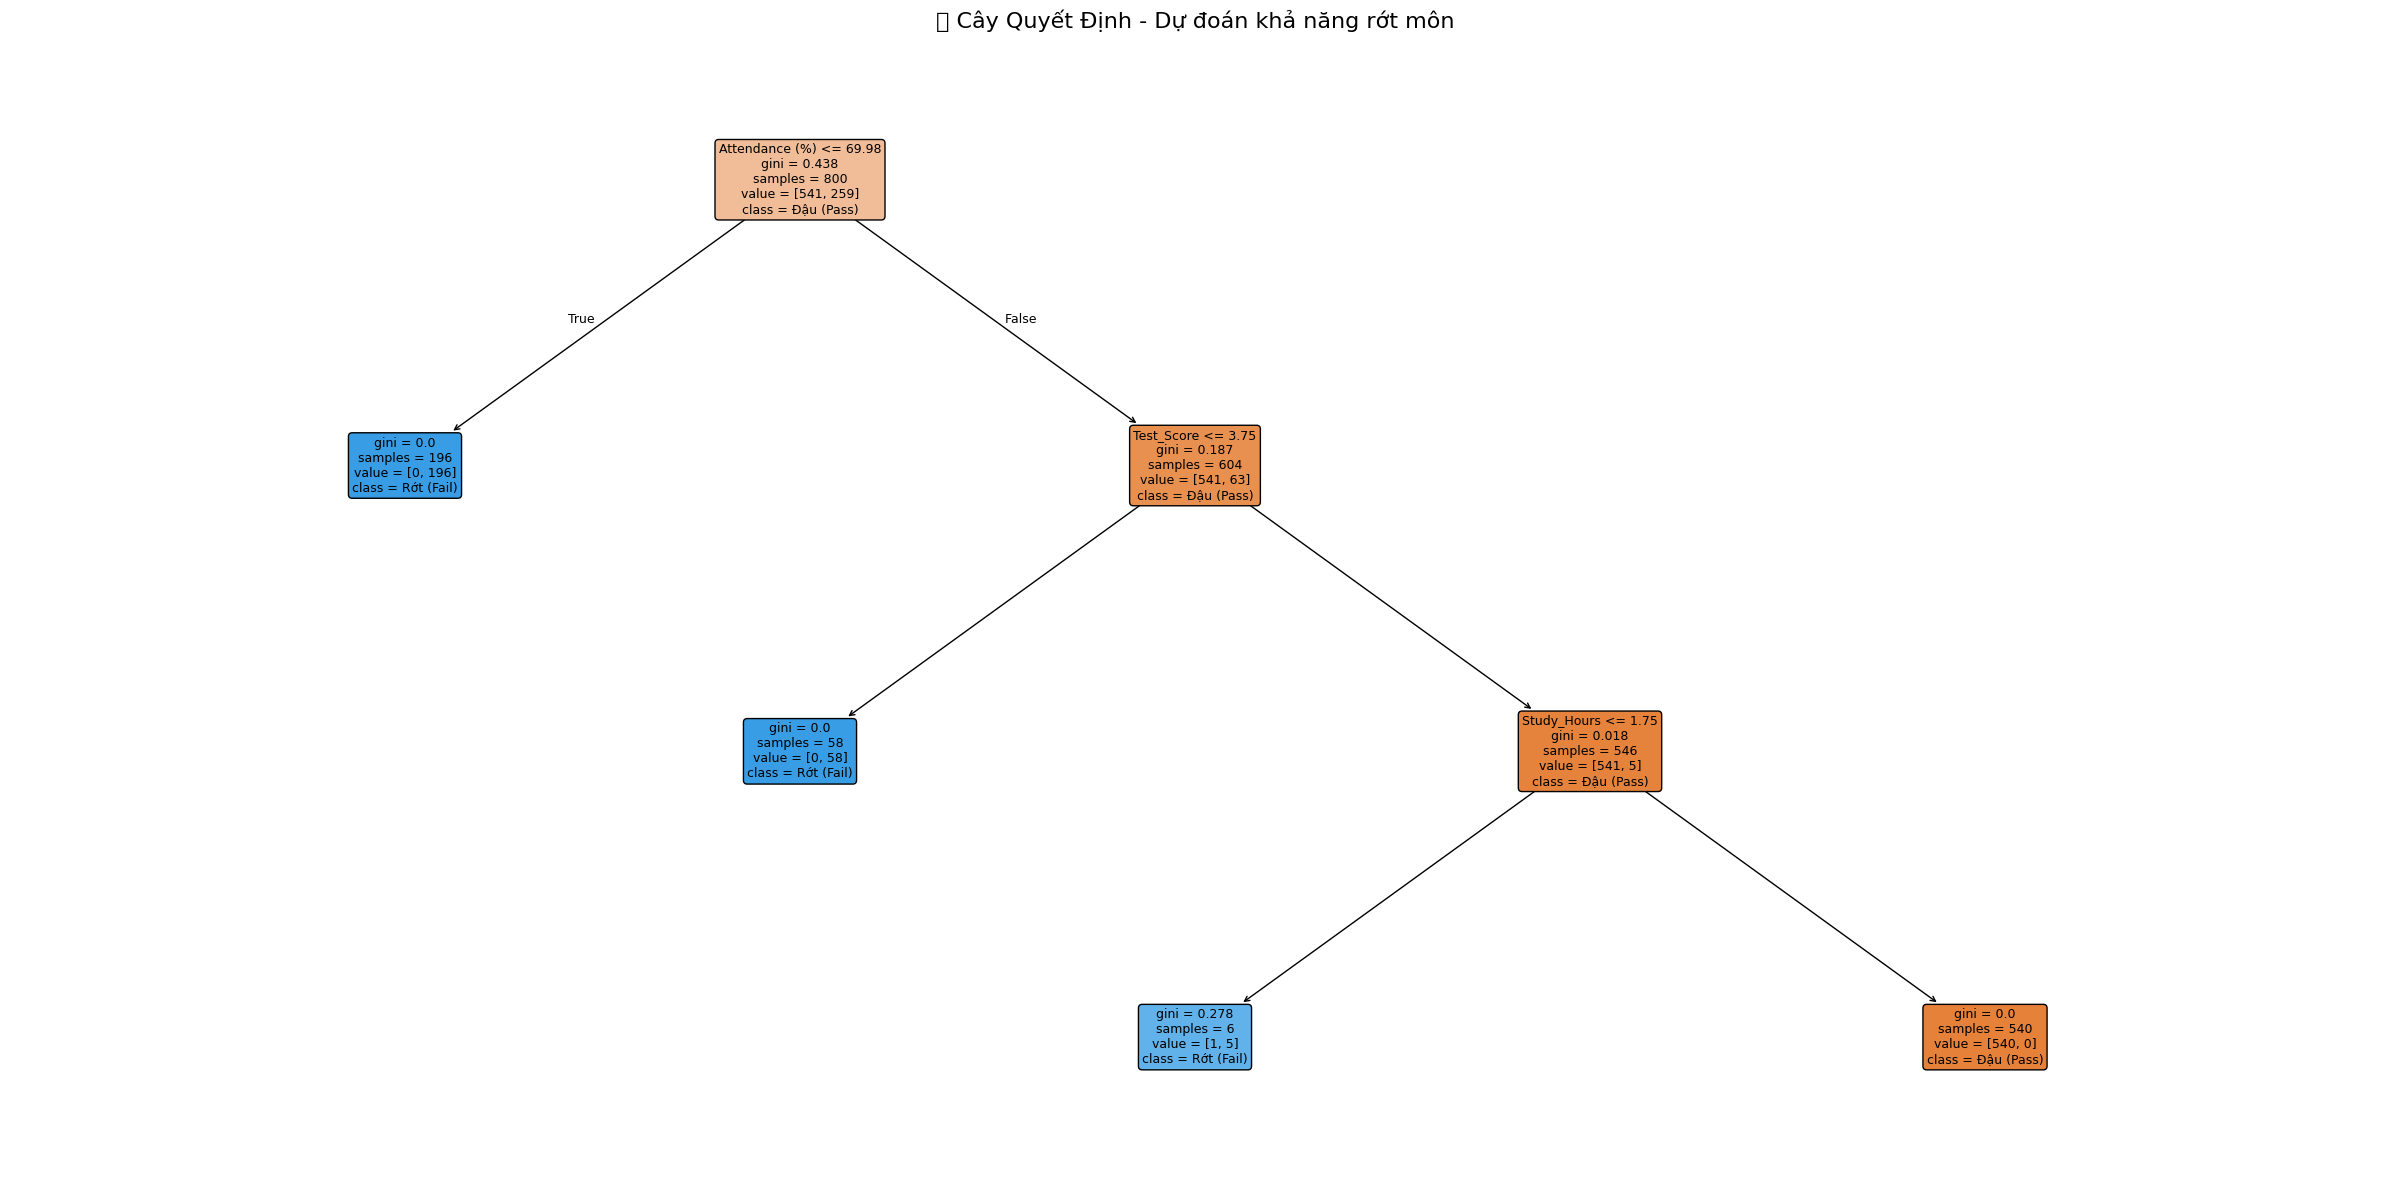

💾 Đã lưu hình cây quyết định: decision_tree.png


In [9]:
# Vẽ cây quyết định dạng đồ họa
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    model,
    feature_names=features,
    class_names=["Đậu (Pass)", "Rớt (Fail)"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
plt.title("🌳 Cây Quyết Định - Dự đoán khả năng rớt môn", fontsize=16)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Đã lưu hình cây quyết định: decision_tree.png")

## 8. Độ quan trọng của các đặc trưng (Feature Importance)

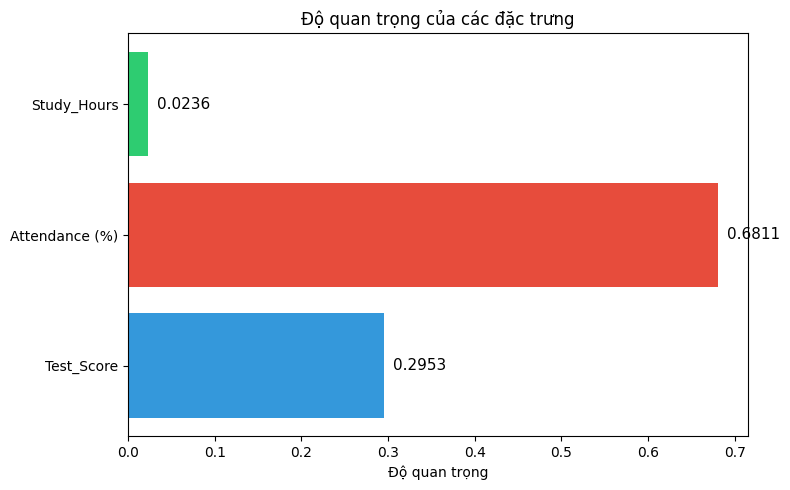


📊 ĐỘ QUAN TRỌNG:
   Attendance (%)       0.6811  ███████████████████████████
   Test_Score           0.2953  ███████████
   Study_Hours          0.0236  


In [10]:
importances = model.feature_importances_

# Vẽ biểu đồ feature importance
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(features, importances, color=["#3498db", "#e74c3c", "#2ecc71"])
ax.set_xlabel("Độ quan trọng")
ax.set_title("Độ quan trọng của các đặc trưng")

for bar, imp in zip(bars, importances):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f"{imp:.4f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

print("\n📊 ĐỘ QUAN TRỌNG:")
for feat, imp in sorted(zip(features, importances), key=lambda x: -x[1]):
    bar = "█" * int(imp * 40)
    print(f"   {feat:<20} {imp:.4f}  {bar}")

## 9. Lưu mô hình & xuất dữ liệu

In [11]:
# Lưu mô hình
joblib.dump(model, MODEL_PATH)
print(f"💾 Đã lưu mô hình: {MODEL_PATH}")

# Xuất dữ liệu đã gán nhãn
output_path = os.path.join("..", "data", "1k_Data_diem_labeled.xlsx")
df_out = df.copy()
df_out["Ket_Qua"] = df_out["Fail"].map({0: "Đậu", 1: "Rớt"})
df_out.to_excel(output_path, index=False)
print(f"💾 Đã xuất dữ liệu có nhãn: {output_path}")

print("\n✅ HOÀN TẤT TRAINING MÔ HÌNH!")

💾 Đã lưu mô hình: decision_tree_model.pkl
💾 Đã xuất dữ liệu có nhãn: ..\data\1k_Data_diem_labeled.xlsx

✅ HOÀN TẤT TRAINING MÔ HÌNH!
